In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f"   GPU name: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
   GPU name: Tesla T4
   GPU memory: 15.6 GB


In [ ]:
# CHANGE With your github username and repo name
!git clone https://github.com/makdadejene/hinge-reddit-proj.git
%cd hinge-reddit-proj

DATA       = Path("data")
LABELS_CSV = DATA / "crop_labels_manual.csv"
POSTS_JSON = DATA / "profile_review_posts(real) (1).json"
CROPS_DIR  = Path("/content/drive/MyDrive/hingeapp_crops")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

Cloning into 'hinge-reddit-proj'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 69 (delta 32), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 2.56 MiB | 5.04 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/hinge-reddit-proj


In [ ]:
IMG_SIZE   = 64
BATCH_SIZE = 64
NUM_EPOCHS = 15
LR         = 1e-3

PERSON_LABEL_NAMES  = ["selfie", "solo", "group", "no_person"]
CONTEXT_LABEL_NAMES = ["outdoors", "nightlife", "sport_gym", "everyday", "animal", "music_performing", "travel_landmark", "food_restaurant"]

PERSON_MODEL_PATH  = "/content/drive/MyDrive/hinge_cnn_person.pth"
CONTEXT_MODEL_PATH = "/content/drive/MyDrive/hinge_cnn_context.pth"


1219 labeled crops


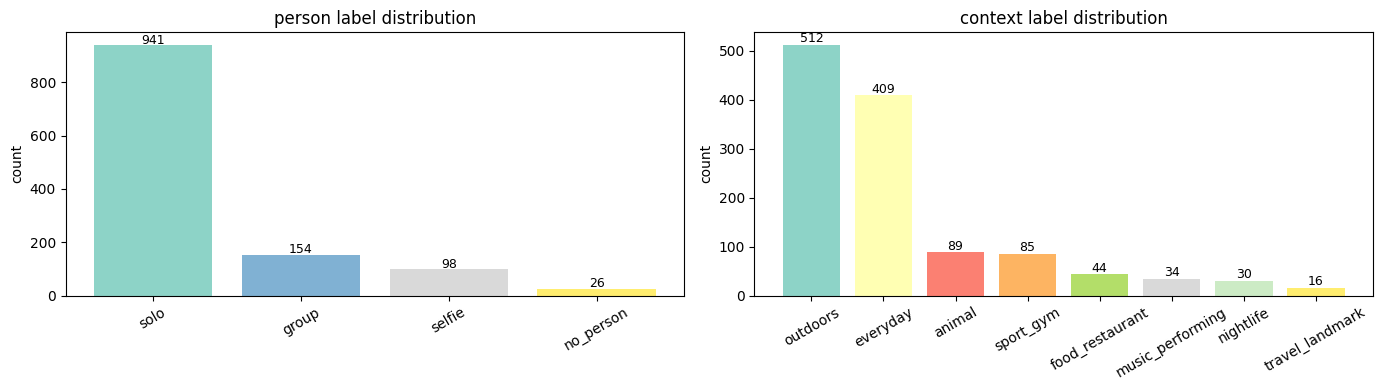

In [ ]:
df = pd.read_csv(LABELS_CSV)
print(f"{len(df)} labeled crops")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

person_counts = df["person"].value_counts()
axes[0].bar(person_counts.index, person_counts.values,
            color=plt.cm.Set3(np.linspace(0, 1, len(person_counts))))
axes[0].set_title("person label distribution")
axes[0].set_ylabel("count")
for i, (label, count) in enumerate(person_counts.items()):
    axes[0].text(i, count + 5, str(count), ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

context_counts = df["context"].value_counts()
axes[1].bar(context_counts.index, context_counts.values,
            color=plt.cm.Set3(np.linspace(0, 1, len(context_counts))))
axes[1].set_title("context label distribution")
axes[1].set_ylabel("count")
for i, (label, count) in enumerate(context_counts.items()):
    axes[1].text(i, count + 5, str(count), ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# merge rare context classes into 'other' and drop no_person
CONTEXT_MERGE = {
    "outdoors":         "outdoors",
    "everyday":         "everyday",
    "animal":           "animal",
    "sport_gym":        "sport_gym",
    "food_restaurant":  "other",
    "music_performing": "other",
    "nightlife":        "other",
    "travel_landmark":  "other",
}

df["context"] = df["context"].map(CONTEXT_MERGE)
df = df[df["person"] != "no_person"].reset_index(drop=True)

PERSON_LABEL_NAMES  = ["selfie", "solo", "group"]
CONTEXT_LABEL_NAMES = ["outdoors", "everyday", "animal", "sport_gym", "other"]

print(f"{len(df)} crops after filtering")
print("\nperson:"); print(df["person"].value_counts())
print("\ncontext:"); print(df["context"].value_counts())

1193 crops after filtering

person:
person
solo      941
group     154
selfie     98
Name: count, dtype: int64

context:
context
outdoors     505
everyday     407
other        120
sport_gym     85
animal        76
Name: count, dtype: int64


In [ ]:
class HingeDataset(Dataset):
    def __init__(self, df, crops_dir, label_col, label2idx, transform=None):
        self.df        = df.reset_index(drop=True)
        self.crops_dir = crops_dir
        self.label_col = label_col
        self.label2idx = label2idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(os.path.join(self.crops_dir, row["filename"])).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.label2idx[row[self.label_col]]


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])



In [ ]:
def make_loaders(df, label_col, label_names):
    label2idx = {l: i for i, l in enumerate(label_names)}
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df[label_col])
    val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df[label_col])

    train_ds = HingeDataset(train_df, CROPS_DIR, label_col, label2idx, train_transform)
    val_ds   = HingeDataset(val_df,   CROPS_DIR, label_col, label2idx, val_transform)
    test_ds  = HingeDataset(test_df,  CROPS_DIR, label_col, label2idx, val_transform)

    counts   = train_df[label_col].value_counts().to_dict()
    weights  = [1.0 / counts[r[label_col]] for _, r in train_df.iterrows()]
    sampler  = WeightedRandomSampler(weights, num_samples=len(train_df), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

    return train_loader, val_loader, test_loader, label2idx


In [ ]:
class HingeCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.3)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.3)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.3)
        )
        self.block4 = nn.Sequential(
    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256), nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2), nn.Dropout(0.25)
)
        self.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(256 * 4 * 4, 512),  # 256 channels, 4x4 spatial
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes),
)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)

In [ ]:
def train_model(label_col, label_names, model_path):
    print(f"\ntraining {label_col} model ({len(label_names)} classes)")
    train_loader, val_loader, test_loader, label2idx = make_loaders(df, label_col, label_names)

    model     = HingeCNN(len(label_names)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(NUM_EPOCHS):

        # training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"epoch {epoch+1}", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        # validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(device)
                labels  = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted      = torch.max(outputs, 1)
                val_total        += labels.size(0)
                val_correct      += (predicted == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_acc  = 100.0 * val_correct / val_total

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        marker = " saved" if val_acc > best_val_acc else ""
        print(f"  epoch [{epoch+1:2d}/{NUM_EPOCHS}] | train loss: {train_loss:.4f}  acc: {train_acc:.1f}% | val loss: {val_loss:.4f}  acc: {val_acc:.1f}%{marker}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)

    print(f"\nbest val acc: {best_val_acc:.2f}%")
    return model, label2idx, label_names, test_loader


In [ ]:
person_model,  person_l2i,  person_names,  person_test  = train_model("person",  PERSON_LABEL_NAMES,  PERSON_MODEL_PATH)
context_model, context_l2i, context_names, context_test = train_model("context", CONTEXT_LABEL_NAMES, CONTEXT_MODEL_PATH)

def evaluate(model, loader, label_names, label_col):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            all_preds.extend(model(images.to(device)).argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    print(f"\n--- {label_col} test results ---")
    print(classification_report(all_labels, all_preds, target_names=label_names, labels=list(range(len(label_names)))))

evaluate(person_model,  person_test,  PERSON_LABEL_NAMES,  "person")
evaluate(context_model, context_test, CONTEXT_LABEL_NAMES, "context")


def predict_all(model, label_names, label_col, model_path):
    label2idx   = {l: i for i, l in enumerate(label_names)}
    model.load_state_dict(torch.load(model_path))
    model.eval()
    full_loader = DataLoader(HingeDataset(df, CROPS_DIR, label_col, label2idx, val_transform), batch_size=64, shuffle=False, num_workers=0)
    preds = {}
    with torch.no_grad():
        for i, (images, _) in enumerate(full_loader):
            for j, pred in enumerate(model(images.to(device)).argmax(1).cpu().numpy()):
                preds[df.iloc[i * 64 + j]["filename"]] = label_names[pred]
    return preds

person_preds  = predict_all(person_model,  PERSON_LABEL_NAMES,  "person",  PERSON_MODEL_PATH)
context_preds = predict_all(context_model, CONTEXT_LABEL_NAMES, "context", CONTEXT_MODEL_PATH)




training person model (3 classes)


epoch 1:   0%|          | 0/14 [00:00<?, ?it/s]

  epoch [ 1/15] | train loss: 2.5681  acc: 34.5% | val loss: 1.1918  acc: 8.4% saved


epoch 2:   0%|          | 0/14 [00:00<?, ?it/s]

  epoch [ 2/15] | train loss: 1.1446  acc: 36.8% | val loss: 1.1176  acc: 13.4% saved


...

  epoch [13/15] | train loss: 1.5267  acc: 29.0% | val loss: 1.5756  acc: 25.7%


epoch 14:   0%|          | 0/14 [00:00<?, ?it/s]

  epoch [14/15] | train loss: 1.5271  acc: 30.4% | val loss: 1.5985  acc: 20.1%


epoch 15:   0%|          | 0/14 [00:00<?, ?it/s]

  epoch [15/15] | train loss: 1.4902  acc: 32.3% | val loss: 1.5820  acc: 24.0%

best val acc: 31.84%

--- person test results ---
              precision    recall  f1-score   support

      selfie       0.09      0.53      0.16        15
        solo       0.75      0.35      0.48       141
       group       0.27      0.30      0.29        23

    accuracy                           0.36       179
   macro avg       0.37      0.40      0.31       179
weighted avg       0.64      0.36      0.42       179


--- context test results ---
              precision    recall  f1-score   support

    outdoors       0.59      0.25      0.35        76
    everyday       0.33      0.07      0.11        61
      animal       0.11      0.33      0.16        12
   sport_gym       0.00      0.00      0.00        12
       other       0.15      0.72      0.25        18

    accuracy                           0.22       179
   macro avg       0.24      0.27      0.18       179
weighted avg       0.39 

In [ ]:
with open(POSTS_JSON) as f:
    posts = json.load(f)

for post in posts:
    post["person_labels"]  = {os.path.basename(p): person_preds[os.path.basename(p)]  for p in post.get("crops", []) if os.path.basename(p) in person_preds}
    post["context_labels"] = {os.path.basename(p): context_preds[os.path.basename(p)] for p in post.get("crops", []) if os.path.basename(p) in context_preds}

OUTPUT_JSON = DATA / "profile_review_posts_labeled.json"
with open(OUTPUT_JSON, "w") as f:
    json.dump(posts, f, indent=2)

print("done")

done
